In [ ]:
with open("/content/Harry Potter and the Order of the Phoenix.txt") as f:
  raw_text=f.read()

In [ ]:
len(raw_text)

1524926

In [ ]:
import re
processed=re.split(r'([,.*:;?_!"()\'\|+]|--|\s+)',raw_text)
result=[items.strip() for items in processed if items.strip()]

In [ ]:
dic=sorted(set(result))
dic.extend(["<|endoftext|>","<|unk|>"])

In [ ]:
vocab={words:no for no,words in enumerate(dic)}


In [ ]:
class SimpleTokenizer:
  def __init__(self,vocab):
    self.str_to_int=vocab
    self.int_to_str={v:k for k,v in vocab.items()}


  def encode(self,text):
    processed=re.split(r'([,.*:;?_!"()\'\|+]|--|\s+)',text)
    processed=[items.strip() for items in processed if items.strip()]
    result=[self.str_to_int[token] if token in self.str_to_int else self.str_to_int["<|unk|>"]  for token in processed ]
    return result

  def decode(self,lis):
    result=[self.int_to_str[token] if token in self.int_to_str else "<|unk|>" for token in lis]
    result=" ".join(result)
    return result


In [ ]:
tokeizer=SimpleTokenizer(vocab)
text1="hello keshv vibhav how are you there my friend"
tokenized=tokeizer.encode(text1)
print(tokenized)
print(tokeizer.decode(tokenized))

[7658, 14533, 14533, 7846, 3427, 14512, 13141, 9393, 6953]
hello <|unk|> <|unk|> how are you there my friend


#WORD2VEC

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 77.7 MB/s eta 0:00:00
ERROR: Operation cancelled by user


In [ ]:
import gensim.downloader as api

In [ ]:
model=api.load("word2vec-google-news-300")

[==========----------------------------------------] 20.7% 344.7/1662.8MB downloaded

#DataPrepare

In [ ]:
!pip install tiktoken

In [ ]:
import tiktoken
import torch

In [ ]:
from torch.utils.data import DataLoader,Dataset

class GPTDatasetV1(Dataset):
  def __init__(self,txt,tokenizer,max_le,stride):
    self.inp=[]
    self.tar=[]
    tokenized=tokenizer.encode(txt,allowed_special={"<|endoftext|>"})
    for i in range(0,len(tokenized)-max_le,stride):
      input=tokenized[i:i+max_le]
      target=tokenized[i+1:i+1+max_le]
      self.inp.append(torch.tensor(input))
      self.tar.append(torch.tensor(target))

  def __len__(self):
    return len(self.inp)

  def __getitem__(self, index) :
    return self.inp[index],self.tar[index]




In [ ]:
def create_dataset_v1(txt,batch_size=4,max_le=256,stride=128,shuffle=True,drop_last=True,num_workers=0):
  tokenizer=tiktoken.get_encoding("gpt2")
  dataset=GPTDatasetV1(txt,tokenizer,max_le,stride)
  dataloader=DataLoader(dataset,batch_size=batch_size,shuffle=shuffle,drop_last=drop_last,num_workers=num_workers)
  return dataloader

In [ ]:
dataset_v1=create_dataset_v1(raw_text,batch_size=8,max_le=4,stride=4,shuffle=False)
data_iter=iter(dataset_v1)
print(next(data_iter))

[tensor([[18308, 14179,   290,   262],
        [ 8284,   286,   262,  9643],
        [  198,    41,   509, 41558],
        [  198,   198,    12,  5870],
        [29485, 16329,   532,   198],
        [   35,   463,  1636,   360],
        [  972,   276,   198,   464],
        [26896,  1110,   286,   262]]), tensor([[14179,   290,   262,  8284],
        [  286,   262,  9643,   198],
        [   41,   509, 41558,   198],
        [  198,    12,  5870, 29485],
        [16329,   532,   198,    35],
        [  463,  1636,   360,   972],
        [  276,   198,   464, 26896],
        [ 1110,   286,   262,  3931]])]


In [ ]:
import numpy as np

In [ ]:
pos_emb=torch.nn.Embedding(4,10)

In [ ]:
input=torch.tensor(np.random.randint(0,200,size=(8,4,10)))
pos_emb=pos_emb(torch.arange(0,4))


#Multihead attention

In [ ]:
import torch
import torch.nn as nn

In [ ]:
class MultiHeadAttention(nn.Module):
  def __init__(self,context_len,d_in,d_out,num_heads,dropout,bias=True):
    super().__init__()

    assert(d_out%num_heads==0),"dout should be div by num_heads chutiye"
    self.num_heads=num_heads
    self.d_out=d_out
    self.head_dim=d_out//num_heads

    self.W_query=nn.Linear(d_in,d_out,bias=bias)
    self.W_key=nn.Linear(d_in,d_out,bias=bias)
    self.W_value=nn.Linear(d_in,d_out,bias=bias)
    self.out_proj=nn.Linear(d_out,d_out)
    self.dropout=nn.Dropout(dropout)
    self.register_buffer(
        "mask",torch.triu(torch.ones(context_len,context_len),diagonal=1)
    )
  def forward(self,x):
    batch_size,num_tokens,d_in=x.shape
    query=self.W_query(x)
    key=self.W_key(x)
    value=self.W_value(x)
    query=query.view(batch_size,num_tokens,self.num_heads,self.head_dim)
    key=key.view(batch_size,num_tokens,self.num_heads,self.head_dim)
    value=value.view(batch_size,num_tokens,self.num_heads,self.head_dim)
    #transpose the mat
    query=query.transpose(1,2)
    key=key.transpose(1,2)
    value=value.transpose(1,2)

    # mul the matrix query * keyT

    attn_score=query @ key.transpose(2,3)
     #mask
    mask=self.mask.bool()[:num_tokens,:num_tokens]
    attn_score=attn_score.masked_fill(mask,-torch.inf)
    attn_score=attn_score/key.shape[-1]**0.5
    attn_score=torch.softmax(attn_score,dim=-1)
    attn_score=self.dropout(attn_score)
    context_vector=attn_score @ value
    context_vector=context_vector.transpose(1,2)
    context_vector=context_vector.flatten(start_dim=2)
    context_vector=self.out_proj(context_vector)
    return context_vector





#LAYER NORM

In [ ]:
class LayerNorm(nn.Module):
  def __init__(self,emb_dim):
    super().__init__()
    self.scale=nn.Parameter(torch.ones(emb_dim))
    self.bias=nn.Parameter(torch.zeros(emb_dim))

  def forward(self,x):
    mean=x.mean(dim=-1,keepdim=True)
    var=x.var(dim=-1,keepdim=True)
    out=(x-mean)/torch.sqrt(var+1e-5)
    out=self.scale*out+self.bias
    return out

#Feed forward

In [ ]:
class GELU(nn.Module):
    def __init__(self):
      super().__init__()


    def forward(self,x):
      return 0.5*x*(1+torch.tanh(
          torch.sqrt(torch.tensor(2/torch.pi))*(x+0.044715*torch.pow(x,3))
      ))

In [ ]:
class FeedForward(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.layers=nn.Sequential(
        nn.Linear(cfg["emb_dim"],4*cfg["emb_dim"]),
        GELU(),
        nn.Linear(4*cfg["emb_dim"],cfg["emb_dim"])
    )

  def forward(self,x):
    return self.layers(x)

#skip connection

In [ ]:
class examplenn(nn.Module):
  def __init__(self,layers):
    super().__init__()
    self.layers=nn.ModuleList(
        nn.Sequential(
            nn.Linear(layers[i],layers[i+1]),
            nn.ReLU()
        )
        for i in range(len(layers)-1)
    )

  def forward(self,x):
    for layer in self.layers:
      shortcut=x;
      x=layer(x)
      if(shortcut.shape[-1]==x.shape[-1]):
        x=x+shortcut
    return x






In [ ]:
def print_loss(model,x):
  out=model(x)
  tar=torch.tensor([[1.0]])
  loss_fn=nn.MSELoss()
  loss=loss_fn(out,tar)

  loss.backward()

  for name,para in model.named_parameters():
    print(f"name {name} : parameter {para.grad}")

In [ ]:
layers=[3,4,1]
model=examplenn(layers)
inp=torch.tensor([1.0,2.3,2.0],dtype=torch.float32)
print_loss(model,inp)

name layers.0.0.weight : parameter tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])
name layers.0.0.bias : parameter tensor([0., 0., 0., 0.])
name layers.1.0.weight : parameter tensor([[0., 0., 0., 0.]])
name layers.1.0.bias : parameter tensor([0.])


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([1, 1])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


# gpt config

In [ ]:
GPT_CONFIG_124M={
    "vocab_size":50257,
    "context_length":256,
    "emb_dim":768,
    "n_layers":12,
    "n_heads":12,
    "drop_rate":0.1,
    "qkv_bias":False
    }

#transformer block

In [ ]:
class TransformerBlock(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.att=MultiHeadAttention(
        d_in=cfg["emb_dim"],
        d_out=cfg["emb_dim"],
        context_len=cfg["context_length"],
        dropout=cfg["drop_rate"],
        bias=cfg["qkv_bias"],
        num_heads=cfg["n_heads"]

    )
    self.ff=FeedForward(cfg)
    self.norm1=LayerNorm(cfg["emb_dim"])
    self.norm2=LayerNorm(cfg["emb_dim"])
    self.drop_shortcut=nn.Dropout(cfg["drop_rate"])

  def forward(self,x):
    shortcut=x
    x=self.norm1(x)
    x=self.att(x)
    x=self.drop_shortcut(x)
    x=x+shortcut
    shortcut=x
    x=self.norm2(x)
    x=self.ff(x)
    x=self.drop_shortcut(x)
    x=x+shortcut
    return x


# gpt model

In [ ]:
class GPTMODEL(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.tok_emb=nn.Embedding(cfg["vocab_size"],cfg["emb_dim"])
    self.pos_emb=nn.Embedding(cfg["context_length"],cfg["emb_dim"])
    self.drop_emb=nn.Dropout(cfg["drop_rate"])
    self.trf_blocks=nn.Sequential(
        *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
    self.final_norm=LayerNorm(cfg["emb_dim"])
    self.out_head=nn.Linear(cfg["emb_dim"],cfg["vocab_size"],bias=False)



  def forward(self,in_idx):
     batch_size,seq_len=in_idx.shape
     tok_embeds=self.tok_emb(in_idx)
     pos_embeds=self.pos_emb(torch.arange(seq_len,device=in_idx.device))
     x=tok_embeds+pos_embeds
     x=self.drop_emb(x)
     x=self.trf_blocks(x)
     x=self.final_norm(x)
     logits=self.out_head(x)
     return logits

In [ ]:
model=GPTMODEL(GPT_CONFIG_124M)
batch = torch.randint(0, GPT_CONFIG_124M["vocab_size"], (2, 4))
out=model(batch)

In [ ]:
sum([p.numel() for p in model.parameters()]) # parameter yaha pe cal kr diya toh isme 124 isliye as output layer ka bhi minus hoga isliye

162419712

In [ ]:
def text_to_token_ids(text, tokenizer):
    return torch.tensor(tokenizer.encode(text)).unsqueeze(0)

def token_ids_to_text(token_ids, tokenizer):
    # Ensure token_ids is on CPU before decoding
    if token_ids.is_cuda:
        token_ids = token_ids.cpu()
    return tokenizer.decode(token_ids.squeeze(0).tolist())

In [ ]:
import os
import urllib.request
import torch
from torch import nn

In [ ]:
file_path="/content/Harry Potter and the Order of the Phoenix.txt"

with open(file_path,"r",encoding="utf-8") as file:
  text_data=file.read()

In [ ]:
len(text_data)

1524926

In [ ]:
import tiktoken
tokenizer=tiktoken.get_encoding("gpt2")

In [ ]:
len(tokenizer.encode(text_data))

385648

In [ ]:
#training data created
train_ratio=0.90
split_idx=int(train_ratio*len(text_data))
train_data=text_data[:split_idx]
val_data=text_data[split_idx:]

torch.manual_seed(123)

train_loader=create_dataset_v1(
    train_data,
    batch_size=2,
    max_le=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
)


val_loader=create_dataset_v1(
    val_data,
    batch_size=2,
    max_le=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
)


In [ ]:
for input,target in train_loader:
  print("input ",input.shape)
  print("target ",target.shape)

input  torch.Size([2, 256])
target  torch.Size([2, 256])
input  torch.Size([2, 256])
target  torch.Size([2, 256])
input  torch.Size([2, 256])
target  torch.Size([2, 256])
input  torch.Size([2, 256])
target  torch.Size([2, 256])
input  torch.Size([2, 256])
target  torch.Size([2, 256])
input  torch.Size([2, 256])
target  torch.Size([2, 256])
input  torch.Size([2, 256])
target  torch.Size([2, 256])
input  torch.Size([2, 256])
target  torch.Size([2, 256])
input  torch.Size([2, 256])
target  torch.Size([2, 256])
input  torch.Size([2, 256])
target  torch.Size([2, 256])
input  torch.Size([2, 256])
target  torch.Size([2, 256])
input  torch.Size([2, 256])
target  torch.Size([2, 256])
input  torch.Size([2, 256])
target  torch.Size([2, 256])
input  torch.Size([2, 256])
target  torch.Size([2, 256])
input  torch.Size([2, 256])
target  torch.Size([2, 256])
input  torch.Size([2, 256])
target  torch.Size([2, 256])
input  torch.Size([2, 256])
target  torch.Size([2, 256])
input  torch.Size([2, 256])
tar

In [ ]:
model=GPTMODEL(GPT_CONFIG_124M)
model.eval()

GPTMODEL(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [ ]:
def calc_loss_batch(input_batch,target_batch,model,device):
  input_batch = input_batch.to(device)
  target_batch = target_batch.to(device)
  logits=model(input_batch)
  loss_fn = nn.CrossEntropyLoss()
  loss = loss_fn(logits.flatten(0,1), target_batch.flatten())
  return loss

In [ ]:
def calc_loss_loader(data_loader,model,device,num_batches=None):
  total_loss=0
  if len(data_loader)==0:
    return float("nan")
  elif num_batches is None:
    num_batches=len(data_loader)

  else:
    num_batches=min(num_batches,len(data_loader))

  for i ,(input_batch,target_batch) in enumerate(data_loader):
    if i< num_batches:
      loss=calc_loss_batch(input_batch,target_batch,model,device)
      total_loss+=loss.item()
    else :
      break
  return total_loss/num_batches


In [ ]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")


model.to(device)
torch.manual_seed(123)

with torch.no_grad():
  train_loss=calc_loss_loader(train_loader,model,device)
  val_loss=calc_loss_loader(val_loader,model,device)

print("train loss : ",train_loss)
print("validation loss : ",val_loss)



train loss :  6.730147616963991
validation loss :  6.652363438760081


#TRAINING THE MODEL

In [ ]:
def train_model_simple(model,train_loader,val_loader,optimizer,device,num_epochs,
                       eval_freq,eval_iter,start_context,tokenizer):
  train_losses,val_losses,track_tokens_seen=[],[],[]
  tokens_seen,global_step=0,-1;


  #main loop
  for epoch in range(num_epochs):
    model.train()
    for input_batch,target_batch in train_loader:
      optimizer.zero_grad()  # reset loss gradient from previuos batch
      loss =calc_loss_batch(input_batch,target_batch,model,device)
      loss.backward() #grad cal for every parameter
      optimizer.step() #update weights w=w-lr*grad
      tokens_seen+=input_batch.numel()
      global_step+=1

      #optional eval step
      if global_step%eval_freq==0:
        train_loss,val_loss=evaluate_model(model,train_loader,val_loader,device,eval_iter)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        track_tokens_seen.append(tokens_seen)
        print(f"Epoch{epoch+1} (step : {global_step:06d}):"
        f" train loss : {train_loss:.4f} val loss : {val_loss:.4f}")
    generate_and_print_sample(model,tokenizer,device,start_context)
  return train_losses,val_losses,track_tokens_seen

In [ ]:
def evaluate_model(model,train_loader,val_loader,device,eval_iter):
  model.eval()
  with torch.no_grad():
    train_loss=calc_loss_loader(train_loader,model,device,num_batches=eval_iter)
    val_loss=calc_loss_loader(val_loader,model,device,num_batches=eval_iter)
  model.train()
  return train_loss,val_loss

In [ ]:
def generate_text_simple(model,idx,max_new_tokens,context_size):
  for _ in range(max_new_tokens):
    idx_cond=idx[:,-context_size:]  ##ye isliye maan le kisi case mein if maan le
    #input context size se bada contexr size 4 and input 10 word ka so last ke 4 word lega and next word predict and add karta rahega
    with torch.no_grad():
     logits=model(idx_cond)

    # Select the last token's logits (current position) and apply softmax
    logits = logits[:, -1, :]
    probas = torch.softmax(logits, dim=-1) # softmax gives probabilities

    # Sample the next token from the probability distribution
    idx_next = torch.multinomial(probas, num_samples=1) # Sample one token based on probabilities

    # Append the sampled token to the sequence
    idx=torch.cat((idx,idx_next),dim=1)
  return idx

In [ ]:
def generate_and_print_sample(model,tokenizer,device,start_context):
  model.eval()
  # Fixed: Changed 'weights' to 'weight'
  context_size=model.pos_emb.weight.shape[0]
  encoded=text_to_token_ids(start_context,tokenizer).to(device)
  with torch.no_grad():
    token_ids=generate_text_simple(
        model=model,idx=encoded,
        max_new_tokens=50,context_size=context_size
    )
  decoded_text=token_ids_to_text(token_ids,tokenizer)
  print(decoded_text.replace("\n"," "))
  model.train()

In [ ]:
import time
start_time=time.time()

torch.manual_seed(123)
model=GPTMODEL(GPT_CONFIG_124M)
model.to(device)
optimizer=torch.optim.AdamW(model.parameters(),lr=0.001,weight_decay=0.1)
num_epocs=10
train_losses,val_losses,track_tokens_seen=train_model_simple(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    num_epochs=num_epocs,
    eval_freq=5,
    eval_iter=10,
    start_context="Tevery effort moves you",
    tokenizer=tokenizer
)

end_time=time.time()
elapsed_time=(end_time-start_time)/60
print(f"train complete in {elapsed_time} minutes")

Epoch1 (step : 000000): train loss : 9.4661 val loss : 9.3950
Epoch1 (step : 000005): train loss : 7.6683 val loss : 7.5015
Epoch1 (step : 000010): train loss : 7.1544 val loss : 7.1086
Epoch1 (step : 000015): train loss : 6.9584 val loss : 7.1028
Epoch1 (step : 000020): train loss : 6.8784 val loss : 6.9901
Epoch1 (step : 000025): train loss : 6.6749 val loss : 6.6288
Epoch1 (step : 000030): train loss : 6.5272 val loss : 6.6674
Epoch1 (step : 000035): train loss : 6.7125 val loss : 6.6359
Epoch1 (step : 000040): train loss : 6.5897 val loss : 6.6175
Epoch1 (step : 000045): train loss : 6.4635 val loss : 6.6413
Epoch1 (step : 000050): train loss : 6.3427 val loss : 6.5302
Epoch1 (step : 000055): train loss : 6.4335 val loss : 6.5702
Epoch1 (step : 000060): train loss : 6.2284 val loss : 6.5216
Epoch1 (step : 000065): train loss : 6.2914 val loss : 6.4370
Epoch1 (step : 000070): train loss : 6.3189 val loss : 6.5383
Epoch1 (step : 000075): train loss : 6.4033 val loss : 6.2921
Epoch1 (

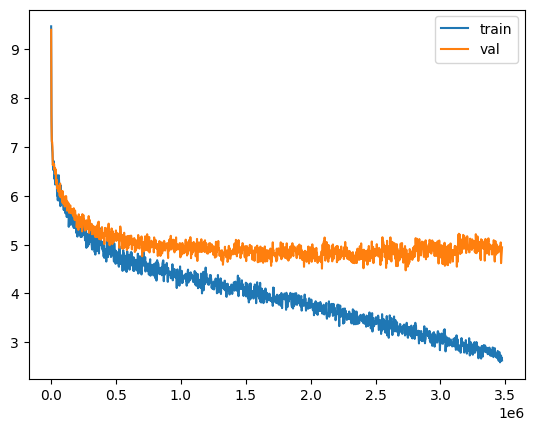

In [ ]:
import matplotlib.pyplot as plt
plt.plot(track_tokens_seen,train_losses,label="train")
plt.plot(track_tokens_seen,val_losses,label="val")
plt.legend()

In [ ]:
eos_id=50256
def generate(model,idx,max_new_tokens,context_size,top_k=None,temperature=0):
  for _ in range(max_new_tokens):
    idx_cond=idx[:,-context_size:]
    with torch.no_grad():
      logits=model(idx_cond)
    logits=logits[:,-1,:]

    if top_k is not None:
      top_logits,_=torch.topk(logits,k=top_k)
      min_val=top_logits[:,-1]
      logits=torch.where(logits<min_val,torch.tensor(float("-inf")).to(logits.device),logits)
    if temperature>0.0:
      logits=logits/temperature

      probs=torch.softmax(logits,dim=-1)
      idx_next=torch.multinomial(probs,num_samples=1)
    else:
      idx_next=torch.argmax(logits,dim=-1,keepdim=True)

    if idx_next==eos_id:
      break

    idx=torch.cat((idx,idx_next),dim=1)

  return idx


In [ ]:
tokenizer=tiktoken.get_encoding("gpt2")
token_ids=generate(
    model=model,
    idx=text_to_token_ids("every effort moves you",tokenizer).to(device),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=10,
    temperature=1.4
)
print(token_ids_to_text(token_ids,tokenizer))

every effort moves you, it was rather well, he would be, he'd have just like


In [ ]:
model.eval()

GPTMODEL(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [ ]:
torch.save({

            "model_state_dict":model.state_dict(),
            "optimizer_state_dict":optimizer.state_dict(),

},"model_and_optimizer.pth")

In [ ]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict()
}, "/content/drive/MyDrive/model_and_optimizer1.pth")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Training second times


In [ ]:
checkpoints=torch.load("/content/drive/MyDrive/model_and_optimizer1.pth")

In [ ]:
model1=GPTMODEL(GPT_CONFIG_124M)
model1.to(device)
model1.load_state_dict(checkpoints["model_state_dict"])

<All keys matched successfully>

In [ ]:
optimizer=torch.optim.AdamW(model.parameters(),lr=0.001,weight_decay=0.1)
optimizer.load_state_dict(checkpoints["optimizer_state_dict"])


In [ ]:
file_path="/content/iLoveMerge.txt"

with open(file_path, "r", encoding="latin-1") as file:
    text_data = file.read()

print(text_data[:1000])

Alice's Adventures in Wonderland

                ALICE'S ADVENTURES IN WONDERLAND

                          Lewis Carroll

               THE MILLENNIUM FULCRUM EDITION 3.0




                            CHAPTER I

                      Down the Rabbit-Hole


  Alice was beginning to get very tired of sitting by her sister
on the bank, and of having nothing to do:  once or twice she had
peeped into the book her sister was reading, but it had no
pictures or conversations in it, `and what is the use of a book,'
thought Alice `without pictures or conversation?'

  So she was considering in her own mind (as well as she could,
for the hot day made her feel very sleepy and stupid), whether
the pleasure of making a daisy-chain would be worth the trouble
of getting up and picking the daisies, when suddenly a White
Rabbit with pink eyes ran close by her.

  There was nothing so VERY remarkable in that; nor did Alice
think it so VERY much out of the way to hear the Rabbit say to
itself, `Oh d

In [ ]:
import requests

url = "https://gist.githubusercontent.com/phillipj/4944029/raw/75ba2243dd5ec2875f629bf5d79f6c1e4b5a8b46/alice_in_wonderland.txt"

response = requests.get(url)
text_data = response.text

  # prin

In [ ]:
print(text_data)

Alice's Adventures in Wonderland

                ALICE'S ADVENTURES IN WONDERLAND

                          Lewis Carroll

               THE MILLENNIUM FULCRUM EDITION 3.0




                            CHAPTER I

                      Down the Rabbit-Hole


  Alice was beginning to get very tired of sitting by her sister
on the bank, and of having nothing to do:  once or twice she had
peeped into the book her sister was reading, but it had no
pictures or conversations in it, `and what is the use of a book,'
thought Alice `without pictures or conversation?'

  So she was considering in her own mind (as well as she could,
for the hot day made her feel very sleepy and stupid), whether
the pleasure of making a daisy-chain would be worth the trouble
of getting up and picking the daisies, when suddenly a White
Rabbit with pink eyes ran close by her.

  There was nothing so VERY remarkable in that; nor did Alice
think it so VERY much out of the way to hear the Rabbit say to
itself, `Oh d

In [ ]:

len(text_data)

2480963

In [ ]:
#training data created
train_ratio=0.90
split_idx=int(train_ratio*len(text_data))
train_data=text_data[:split_idx]
val_data=text_data[split_idx:]

torch.manual_seed(123)

train_loader=create_dataset_v1(
    train_data,
    batch_size=2,
    max_le=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
)


val_loader=create_dataset_v1(
    val_data,
    batch_size=2,
    max_le=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
)


In [ ]:
len(train_loader)

1122

In [ ]:
import time
start_time=time.time()

torch.manual_seed(123)
optimizer=torch.optim.AdamW(model.parameters(),lr=0.01)
num_epocs=10
train_losses,val_losses,track_tokens_seen=train_model_simple(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    num_epochs=num_epocs,
    eval_freq=5,
    eval_iter=10,
    start_context="every effort moves you",
    tokenizer=tokenizer
)

end_time=time.time()
elapsed_time=(end_time-start_time)/60
print(f"train complete in {elapsed_time} minutes")

Epoch1 (step : 000000): train loss : 7.9784 val loss : 7.9838
Epoch1 (step : 000005): train loss : 6.7658 val loss : 6.4348
Epoch1 (step : 000010): train loss : 6.3700 val loss : 6.1203
Epoch1 (step : 000015): train loss : 6.3455 val loss : 6.2891
Epoch1 (step : 000020): train loss : 6.3444 val loss : 6.2272
Epoch1 (step : 000025): train loss : 6.1903 val loss : 5.8198
Epoch1 (step : 000030): train loss : 5.9743 val loss : 5.9137
Epoch1 (step : 000035): train loss : 6.0112 val loss : 6.0261
Epoch1 (step : 000040): train loss : 6.0774 val loss : 5.8184
Epoch1 (step : 000045): train loss : 6.1924 val loss : 5.9870
Epoch1 (step : 000050): train loss : 5.9975 val loss : 5.9233
Epoch1 (step : 000055): train loss : 6.1294 val loss : 5.7933
Epoch1 (step : 000060): train loss : 6.2010 val loss : 5.8461
Epoch1 (step : 000065): train loss : 5.8301 val loss : 5.8374
Epoch1 (step : 000070): train loss : 6.0106 val loss : 5.8548
Epoch1 (step : 000075): train loss : 6.0033 val loss : 5.7587
Epoch1 (

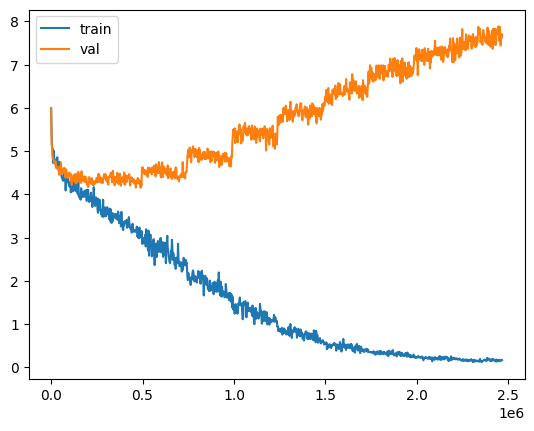

In [ ]:
import matplotlib.pyplot as plt
plt.plot(track_tokens_seen,train_losses,label="train")
plt.plot(track_tokens_seen,val_losses,label="val")
plt.legend()

In [ ]:
eos_id=50256
def generate(model,idx,max_new_tokens,context_size,top_k=None,temperature=0):
  for _ in range(max_new_tokens):
    idx_cond=idx[:,-context_size:]
    with torch.no_grad():
      logits=model(idx_cond)
    logits=logits[:,-1,:]

    if top_k is not None:
      top_logits,_=torch.topk(logits,k=top_k)
      min_val=top_logits[:,-1]
      logits=torch.where(logits<min_val,torch.tensor(float("-inf")).to(logits.device),logits)
    if temperature>0.0:
      logits=logits/temperature

      probs=torch.softmax(logits,dim=-1)
      idx_next=torch.multinomial(probs,num_samples=1)
    else:
      idx_next=torch.argmax(logits,dim=-1,keepdim=True)

    if idx_next==eos_id:
      break

    idx=torch.cat((idx,idx_next),dim=1)

  return idx


In [ ]:
tokenizer=tiktoken.get_encoding("gpt2")
token_ids=generate(
    model=model,
    idx=text_to_token_ids("every effort moves you",tokenizer).to(device),
    max_new_tokens=30,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=10,
    temperature=1.4
)
print(token_ids_to_text(token_ids,tokenizer))

every effort moves you. . . let it drown. . . ."
Wormtail was speaking.
"A day," muttered the whelery beneath his steam


In [ ]:
model.out_head.weight

Parameter containing:
tensor([[-0.1272,  0.0417,  0.0593,  ..., -0.1036, -0.0087,  0.1219],
        [-0.0173,  0.0399, -0.0820,  ..., -0.0707,  0.0969, -0.0064],
        [ 0.0277,  0.0434,  0.0765,  ..., -0.1156, -0.0705,  0.0618],
        ...,
        [ 0.0402,  0.0583,  0.0947,  ..., -0.1109, -0.0855,  0.0657],
        [ 0.0162,  0.0186,  0.0280,  ...,  0.0171, -0.0583,  0.0206],
        [ 0.0261,  0.0433,  0.0829,  ..., -0.1009, -0.0908,  0.0713]],
       device='cuda:0', requires_grad=True)

In [ ]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict()
}, "/content/drive/MyDrive/model_and_optimizer1.pth")